[TEST ]: 100%|███████████████████████████████████████████████████████████████████| 6561/6561 [00:00<00:00, 6578.76it/s]


총 이미지(라벨) 수: 64,369장
불/연기 없음 (Background 이미지): 20,117장

클래스 0 (Fire (0)): 41,752개 Bounding Boxes
클래스 1 (Smoke (1)): 30,371개 Bounding Boxes


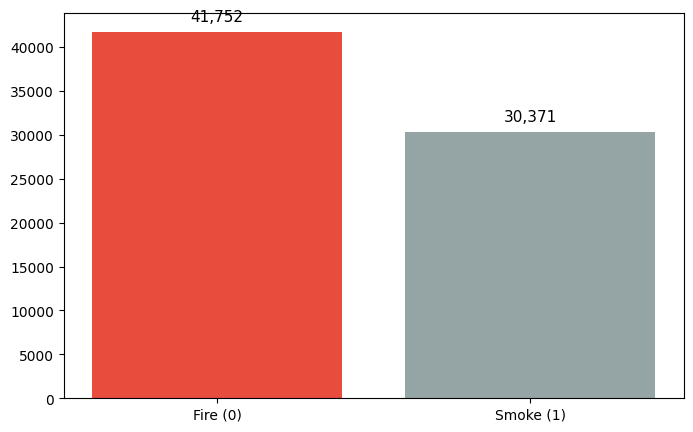

In [9]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

def check_final_distribution(dataset_dir, class_names, splits=['train', 'val', 'test']):
    
    class_counts = {cls_id: 0 for cls_id in class_names.keys()}
    empty_labels = 0
    total_images = 0
    
    for split in splits:
        lbl_dir = Path(dataset_dir) / split / "labels"
        
        if not lbl_dir.exists():
            continue
            
        txt_files = list(lbl_dir.glob("*.txt"))
        total_images += len(txt_files)
        
        for txt_file in tqdm(txt_files, desc=f"[{split.upper():<5}]"):
            with open(txt_file, 'r', encoding='utf-8') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
                
            if not lines:
                empty_labels += 1
                continue
                
            for line in lines:
                try:
                    cls_id = int(line.split()[0])
                    if cls_id in class_counts:
                        class_counts[cls_id] += 1
                except ValueError:
                    continue
                    
    print(f"총 이미지: {total_images:,}장")
    print(f"불/연기 없음: {empty_labels:,}장\n")
    
    for cls_id, count in class_counts.items():
        print(f"클래스 {cls_id} ({class_names[cls_id]}): {count:,}개 Bounding Boxes")
    
    labels = [class_names[k] for k in class_counts.keys()]
    counts = list(class_counts.values())
    
    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, counts, color=['#e74c3c', '#95a5a6'])
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (max(counts)*0.02), 
                 f"{int(yval):,}", ha='center', va='bottom', fontsize=11)
        
    plt.show()

DATASET_DIR = "../dataset" 

final_mapping = {0: 'Fire (0)', 1: 'Smoke (1)'}

check_final_distribution(DATASET_DIR, final_mapping)